In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
sns.set_style('whitegrid')
sns.set_palette("Set2")

# Leer los datos

In [69]:
df_fe = pd.read_csv("../../../data/respuestas_fede.csv")
print("Shape of data: ", df_fe.shape)

# globales
marmol = df_fe.loc[df_fe["escuela"] == "Colegio Modelo Mármol"]
mantovani = df_fe.loc[df_fe["escuela"] == "Escuela Nueva Juan Mantovani"]
cant_total = len(df_fe)
cant_marmol = len(marmol)
cant_mantovani = len(mantovani)

# genero
cant_marmol_masc = len(marmol[marmol['genero']=="Masculino"])
cant_marmol_fem = len(marmol[marmol['genero']=="Femenino"])
cant_marmol_otro = len(marmol[marmol['genero']=="Otro"])
cant_mantovani_masc = len(mantovani[mantovani['genero']=="Masculino"])
cant_mantovani_fem = len(mantovani[mantovani['genero']=="Femenino"])
cant_mantovani_otro = len(mantovani[mantovani['genero']=="Otro"])

# grados
cant_marmol_quinto = len(marmol[marmol['grado']=="Quinto"])
cant_marmol_sexto = len(marmol[marmol['grado']=="Sexto"])
cant_mantovani_cuarto = len(mantovani[mantovani['grado']=="Cuarto"])
cant_mantovani_quinto = len(mantovani[mantovani['grado']=="Quinto"])
cant_mantovani_sexto = len(mantovani[mantovani['grado']=="Sexto"])

# nose que es la nube
nube_nose_totales   = df_fe    ["que_es_nube"].value_counts()["No sé"]
nube_nose_marmol    = marmol   ["que_es_nube"].value_counts()["No sé"]
nube_nose_mantovani = mantovani["que_es_nube"].value_counts()["No sé"]

# no se nube grados
nube_nose_marmol_quinto = marmol[marmol['grado']=="Quinto"]["que_es_nube"].value_counts()["No sé"]
nube_nose_marmol_sexto = marmol[marmol['grado']=="Sexto"]["que_es_nube"].value_counts()["No sé"]
nube_nose_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["que_es_nube"].value_counts()["No sé"]
nube_nose_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["que_es_nube"].value_counts()["No sé"]
nube_nose_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["que_es_nube"].value_counts()["No sé"]

# no se nube generos
nube_nose_marmol_masc    = marmol[marmol['genero']=="Masculino"]["que_es_nube"].value_counts()["No sé"]
nube_nose_marmol_fem     = marmol[marmol['genero']=="Femenino"]["que_es_nube"].value_counts()["No sé"]
nube_nose_mantovani_masc = mantovani[mantovani['genero']=="Masculino"]["que_es_nube"].value_counts()["No sé"]
nube_nose_mantovani_fem  = mantovani[mantovani['genero']=="Femenino"]["que_es_nube"].value_counts()["No sé"]

fig_name_prefix = 'afirmaciones_nube'
file_ext = '.png'
dpi_value = 200
include_title = True

def analizarMisc(val):
    lista = val.split(",")
    misc = 0
    not_misc = 0
    if(lista == ["0"]): # Si no seleccionaron ninguna rta, es porque contestaron no se en la pregunta anterior
        return "Sin\nRta." 
    
    # respuestas sin misconception, # not_misc
    if "Lanubemepermiteguardarlasfotosyvideosdelcelular" in lista:
        not_misc = not_misc + 1
    if "InstagramyTikTokusanlanubeparacompartirsusvideos" in lista:
        not_misc = not_misc + 1
    if "Sepuedeusarlanubeparajugarjuegossininstalarlos" in lista:
        not_misc = not_misc + 1
    if "GoogleMapsdescargasusmapasdelanube" in lista:
        not_misc = not_misc + 1

    # respuestas con misconception, # misc
    if "PodemosutilizarlanubesinconexiónaInternet" in lista:
        misc = misc + 1
    if "Sinlanubeseríaimposibleescucharmúsicaenelcelular" in lista:
        misc = misc + 1
    if "Sinlanubenoseríaposiblehacerllamadasporcelular" in lista:
        misc = misc + 1
    if "Sinlanubeseríaimposiblesacarfotosconelcelular" in lista:
        misc = misc + 1
    
    if(not_misc == misc):
        return "Iguales\nMisc. y\nNo Misc."
    if(misc == 0):
        return "Ninguna\nMisc."
    if(not_misc == 0):
        return "Todas\nMisc."
    if(not_misc > misc):        
        return "Minoría\nMisc."
    if(misc > not_misc):
        return "Mayoría\nMisc."

Shape of data:  (369, 22)


# Afirmaciones sobre la nube

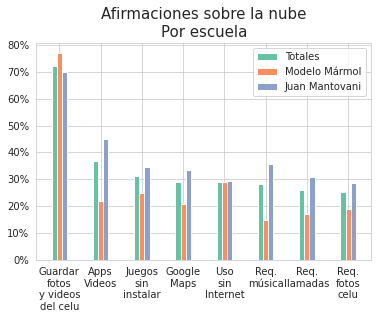

In [70]:
# Afirmaciones sobre la nube
data_total = df_fe["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total - nube_nose_totales).sort_values(ascending=False)
data_marmol = marmol["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol - nube_nose_marmol).sort_values(ascending=False)
data_mantovani = mantovani["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani - nube_nose_mantovani).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1)
result = result.rename( columns={ 0:'Totales',
                                  1:'Modelo Mármol',
                                  2:'Juan Mantovani'},
                        index= {"Lanubemepermiteguardarlasfotosyvideosdelcelular": "Guardar\nfotos\ny videos\ndel celu",
                                "InstagramyTikTokusanlanubeparacompartirsusvideos": "Apps\nVideos",
                                "Sepuedeusarlanubeparajugarjuegossininstalarlos": "Juegos\nsin\ninstalar",
                                "GoogleMapsdescargasusmapasdelanube": "Google\nMaps",
                                "PodemosutilizarlanubesinconexiónaInternet": "Uso\nsin\nInternet",
                                "Sinlanubeseríaimposibleescucharmúsicaenelcelular": "Req.\nmúsica",
                                "Sinlanubenoseríaposiblehacerllamadasporcelular": "Req.\nllamadas",
                                "Sinlanubeseríaimposiblesacarfotosconelcelular": "Req.\nfotos\ncelu"
                                }).fillna(0)

result = result.reindex(["Guardar\nfotos\ny videos\ndel celu","Apps\nVideos","Juegos\nsin\ninstalar","Google\nMaps","Uso\nsin\nInternet","Req.\nmúsica","Req.\nllamadas","Req.\nfotos\ncelu"])

bar_width = 0.25

br1 = [1, 3, 5, 7, 9, 11, 13, 15]
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales']       , width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'] , width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("Afirmaciones sobre la nube\nPor escuela", fontsize=15)
plt.xticks([r + bar_width for r in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_por_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* En esta pregunta se permiten varias respuestas
* solo contestaban esta pregunta los chicos que habian contestado distinto a no se en la pregunta anterior
* El Mantovani elige un 25% más las respuestas "Las apps las usan para compartir sus videos" y "Sin la nube no se podría escuchar música en el celular" un 20% mas. Tambien eligen un 10% más "Permite jugar juegos sin instalarlos", "Google maps la utiliza para sus videos", "Es requerida para realizar llamadas" y "Es requerida para sacar fotos con el celular"
* Mas del 70% elige la opcion de guardar fotos y videos. El resto de las respuestas estan balanceadas en porcentaje entre 20 y 40

In [71]:
# Promedio en cantidad de respuestas - Afirmaciones sobre la nube
data_total = df_fe["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_marmol = marmol["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani = mantovani["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()

dfs = [data_total, data_marmol, data_mantovani]
labels = ['Totales','Modelo Marmol','Juan Mantovani']

result = pd.DataFrame(data=[dfs], columns=labels)
print("Promedio en cantidad de respuestas - Afirmaciones sobre la nube")
result.head()

Promedio en cantidad de respuestas - Afirmaciones sobre la nube


,Totales,Modelo Marmol,Juan Mantovani
0,2.149051,1.551724,2.535714


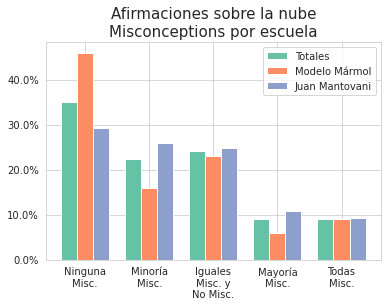

In [72]:
# Con misconception vs Sin Misconception - Agrupando No se - Afirmaciones sobre la nube
data_total = df_fe["afirmaciones_nube"].str.replace(" ", "")
data_marmol = marmol["afirmaciones_nube"].str.replace(" ", "")
data_mantovani = mantovani["afirmaciones_nube"].str.replace(" ", "")

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename( columns={ 0:'Totales',
                                  1:'Modelo Mármol',
                                  2:'Juan Mantovani'}).fillna('0')

dfs = [result["Totales"].apply(analizarMisc).value_counts(),
       result["Modelo Mármol"].apply(analizarMisc).value_counts(),
       result["Juan Mantovani"].apply(analizarMisc).value_counts()]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"})

result = result.reindex(["Sin\nRta.", 
                         "Ninguna\nMisc.",
                         "Minoría\nMisc.", 
                         "Iguales\nMisc. y\nNo Misc.",
                         "Mayoría\nMisc.",
                         "Todas\nMisc."])

# restamos las no respuestas de los valores null de los correspondientes colegios
result.at['Sin\nRta.', 'Modelo Mármol'] = result.loc['Sin\nRta.','Modelo Mármol'] - cant_mantovani
result.at['Sin\nRta.', 'Juan Mantovani'] = result.loc['Sin\nRta.','Juan Mantovani'] - cant_marmol

result = result.drop("Sin\nRta.")
# no las vamos a graficar (estamos graficando solo a los que responden la pregunta y sacando promedio con el nro de respuestas por colegio)
# aun asi mantengo el calculo por si las utilizamos en algun momento

bar_width = 0.25

br1 = np.arange(len(result['Totales']))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'].div(cant_total - nube_nose_totales)             , width=bar_width , label = 'Totales')
plt.bar(br2,result['Modelo Mármol'].div(cant_marmol - nube_nose_marmol)       , width=bar_width , label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'].div(cant_mantovani - nube_nose_mantovani), width=bar_width , label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("Afirmaciones sobre la nube\nMisconceptions por escuela", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_misco_agregadas_por_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* Se dividieron las respuestas con misc. y las que no, se agruparon las respuestas de cada individuo en 5 categorías para representar el gradiente de "misconceptions" en cuanto a afirmaciones sobre la nube.
* Felizmente, el porcentaje más alto es el que se corresponde a los que eligen entre sus respuestas un conjunto que no tiene misconceptions.
* Minoría de Misconceptions e iguales cantidades se distribuyen de manera similar en el mantovani, cerca de un 20%, en el Mármol este porcentaje está cerca de 15%.
* Finalmente la minoría corresponde a mayoría de misconceptions o todas misconceptions.
* A grandes rasgos, cerca de un 60% contesta mayormente sin misconceptions en el Modelo mármol y cerca de un 55% en el Mantovani.
* Cerca de un 15% contesta con mayoría de misconceptions en el Modelo Mármol y el Mantovani

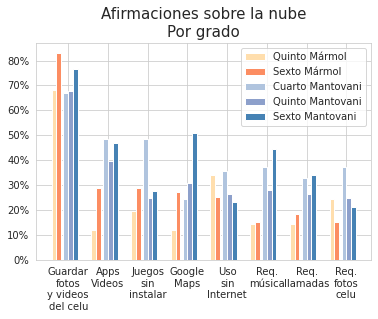

In [73]:
# Afirmaciones sobre la nube según grado
# data_total = df_fe["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)

data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol_quinto - nube_nose_marmol_quinto).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol_sexto - nube_nose_marmol_sexto).sort_values(ascending=False)

data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_cuarto - nube_nose_mantovani_cuarto).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_quinto - nube_nose_mantovani_quinto).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_sexto - nube_nose_mantovani_sexto).sort_values(ascending=False)

dfs = [data_marmol_quinto, data_marmol_sexto, data_mantovani_cuarto, data_mantovani_quinto, data_mantovani_sexto]

result = pd.concat(dfs, axis=1)
result = result.rename( columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                        index= {"Lanubemepermiteguardarlasfotosyvideosdelcelular": "Guardar\nfotos\ny videos\ndel celu",
                                "InstagramyTikTokusanlanubeparacompartirsusvideos": "Apps\nVideos",
                                "Sepuedeusarlanubeparajugarjuegossininstalarlos": "Juegos\nsin\ninstalar",
                                "GoogleMapsdescargasusmapasdelanube": "Google\nMaps",
                                "PodemosutilizarlanubesinconexiónaInternet": "Uso\nsin\nInternet",
                                "Sinlanubeseríaimposibleescucharmúsicaenelcelular": "Req.\nmúsica",
                                "Sinlanubenoseríaposiblehacerllamadasporcelular": "Req.\nllamadas",
                                "Sinlanubeseríaimposiblesacarfotosconelcelular": "Req.\nfotos\ncelu"
                                }).fillna(0)

result = result.reindex(["Guardar\nfotos\ny videos\ndel celu","Apps\nVideos","Juegos\nsin\ninstalar","Google\nMaps","Uso\nsin\nInternet","Req.\nmúsica","Req.\nllamadas","Req.\nfotos\ncelu"])

bar_width = 0.12

ticks = np.arange(len(result))

br_marmol_quinto = ticks
br_marmol_sexto = [x + bar_width for x in br_marmol_quinto]

br_mantovani_cuarto = [x + 1.5* bar_width for x in br_marmol_sexto]
br_mantovani_quinto = [x + bar_width for x in br_mantovani_cuarto]
br_mantovani_sexto  = [x + bar_width for x in br_mantovani_quinto]

plt.bar(br_marmol_quinto,    result['Quinto Mármol'], width=bar_width, label = 'Quinto Mármol'      , color='navajowhite')
plt.bar(br_marmol_sexto,     result['Sexto Mármol'], width=bar_width, label = 'Sexto Mármol'        , color='C1')
plt.bar(br_mantovani_cuarto, result['Cuarto Mantovani'], width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br_mantovani_quinto, result['Quinto Mantovani'], width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br_mantovani_sexto,  result['Sexto Mantovani'], width=bar_width, label = 'Sexto Mantovani'  , color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("Afirmaciones sobre la nube\nPor grado", fontsize=15)
ticks = [x + 3*bar_width for x in ticks]
plt.xticks(ticks, result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_por_grado_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* En esta pregunta se permiten varias respuestas
* Mármol: "Guardar fotos y videos..." es elegida un 15% más en 6to. "Las apps las usan para compartir..." es elegida un 10% más junto con "Google maps"
* Mantovani: Curiosamente, la opción de "Juegos sin instalar" es elegida un 20% menos en 5to y 6to. "Google maps", un 20% más en 6to y finalmente "Uso sin internet" y "Requerida para sacar fotos con el celu" bajan un 10% y 15% respectivamente. 

In [74]:
# Promedio en cantidad de respuestas - Afirmaciones sobre la nube según grado
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]
labels = ['Quinto Marmol','Sexto Marmol','Cuarto Mantovani','Quinto Mantovani','Sexto Mantovani']

result = pd.DataFrame(data=[dfs], columns=labels)
print("Promedio en cantidad de respuestas - Afirmaciones sobre la nube según grado")
result.head()

Promedio en cantidad de respuestas - Afirmaciones sobre la nube según grado


,Quinto Marmol,Sexto Marmol,Cuarto Mantovani,Quinto Mantovani,Sexto Mantovani
0,1.301587,1.743902,2.795181,2.2875,2.508197


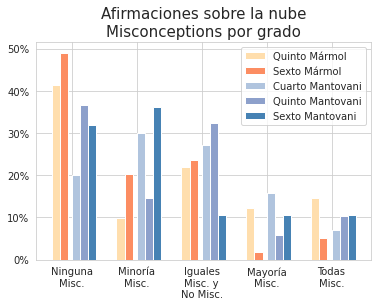

In [75]:
# Con misconception vs Sin Misconception - Agrupando No se - Afirmaciones sobre la nube
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["afirmaciones_nube"].str.replace(" ", "")
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["afirmaciones_nube"].str.replace(" ", "")

data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["afirmaciones_nube"].str.replace(" ", "")
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["afirmaciones_nube"].str.replace(" ", "")
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["afirmaciones_nube"].str.replace(" ", "")

dfs = [data_marmol_quinto, data_marmol_sexto, data_mantovani_cuarto, data_mantovani_quinto, data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename( columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'}).fillna('0')

dfs = [result["Quinto Mármol"].apply(analizarMisc).value_counts(),
       result["Sexto Mármol"].apply(analizarMisc).value_counts(),
       result["Cuarto Mantovani"].apply(analizarMisc).value_counts(),
       result["Quinto Mantovani"].apply(analizarMisc).value_counts(),
       result["Sexto Mantovani"].apply(analizarMisc).value_counts()]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'})

result = result.reindex(["Sin\nRta.", 
                         "Ninguna\nMisc.",
                         "Minoría\nMisc.", 
                         "Iguales\nMisc. y\nNo Misc.",
                         "Mayoría\nMisc.",
                         "Todas\nMisc."])

# Restamos las no respuestas de los valores null de los correspondientes colegios y grados
result.at['Sin\nRta.', 'Quinto Mármol'] = result.loc['Sin\nRta.','Quinto Mármol'] - cant_mantovani - cant_marmol_sexto
result.at['Sin\nRta.', 'Sexto Mármol'] = result.loc['Sin\nRta.','Sexto Mármol'] - cant_mantovani - cant_marmol_quinto
result.at['Sin\nRta.', 'Cuarto Mantovani'] = result.loc['Sin\nRta.','Cuarto Mantovani'] - cant_marmol - cant_mantovani_quinto - cant_mantovani_sexto
result.at['Sin\nRta.', 'Quinto Mantovani'] = result.loc['Sin\nRta.','Quinto Mantovani'] - cant_marmol - cant_mantovani_cuarto - cant_mantovani_sexto
result.at['Sin\nRta.', 'Sexto Mantovani'] = result.loc['Sin\nRta.','Sexto Mantovani'] - cant_marmol - cant_mantovani_cuarto - cant_mantovani_quinto

result = result.drop("Sin\nRta.")

bar_width = 0.25

br1 = [1, 3, 5, 7, 9]
br2 = [x + bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x + bar_width for x in br3]
br5 = [x + bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol'].div(cant_marmol_quinto - nube_nose_marmol_quinto)         , width=bar_width , label = "Quinto Mármol"   , color='navajowhite')
plt.bar(br2, result['Sexto Mármol'].div(cant_marmol_sexto - nube_nose_marmol_sexto)            , width=bar_width , label = "Sexto Mármol"    , color='C1')
plt.bar(br3, result['Cuarto Mantovani'].div(cant_mantovani_cuarto - nube_nose_mantovani_cuarto), width=bar_width , label = "Cuarto Mantovani", color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'].div(cant_mantovani_quinto - nube_nose_mantovani_quinto), width=bar_width , label = "Quinto Mantovani", color='C2')
plt.bar(br5, result['Sexto Mantovani'].div(cant_mantovani_sexto - nube_nose_mantovani_sexto)   , width=bar_width , label = "Sexto Mantovani" , color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("Afirmaciones sobre la nube\nMisconceptions por grado", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_misco_agregadas_por_grado_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* En el modelo y mantovani aumenta con los grados los que contestan mayormente sin misconception. Pasa de cerca de un 50% a 70% en ambos.
* Mayormente misc baja en marmol de un 25% a un 10% y en el mantovani de 25% a 20%

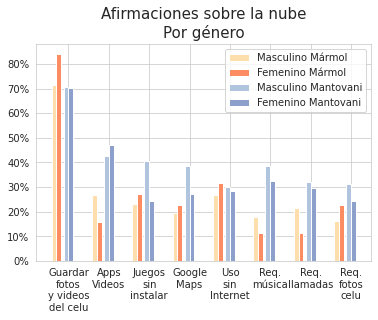

In [76]:
# Afirmaciones sobre la nube
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol_masc - nube_nose_marmol_masc).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol_fem - nube_nose_marmol_fem).sort_values(ascending=False)

data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_masc - nube_nose_mantovani_masc).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_fem - nube_nose_mantovani_fem).sort_values(ascending=False)

dfs = [data_marmol_mas, data_marmol_fem, data_mantovani_mas, data_mantovani_fem]

result = pd.concat(dfs, axis=1)
result = result.rename( columns={0: "Masculino Mármol",
                                1: "Femenino Mármol",
                                2: "Masculino Mantovani",
                                3: "Femenino Mantovani"},
                        index= {"Lanubemepermiteguardarlasfotosyvideosdelcelular": "Guardar\nfotos\ny videos\ndel celu",
                                "InstagramyTikTokusanlanubeparacompartirsusvideos": "Apps\nVideos",
                                "Sepuedeusarlanubeparajugarjuegossininstalarlos": "Juegos\nsin\ninstalar",
                                "GoogleMapsdescargasusmapasdelanube": "Google\nMaps",
                                "PodemosutilizarlanubesinconexiónaInternet": "Uso\nsin\nInternet",
                                "Sinlanubeseríaimposibleescucharmúsicaenelcelular": "Req.\nmúsica",
                                "Sinlanubenoseríaposiblehacerllamadasporcelular": "Req.\nllamadas",
                                "Sinlanubeseríaimposiblesacarfotosconelcelular": "Req.\nfotos\ncelu"
                                }).fillna(0)

result = result.reindex(["Guardar\nfotos\ny videos\ndel celu","Apps\nVideos","Juegos\nsin\ninstalar","Google\nMaps","Uso\nsin\nInternet","Req.\nmúsica","Req.\nllamadas","Req.\nfotos\ncelu"])

bar_width = 0.12

ticks = np.arange(len(result))

b1 = ticks
b2 = [x + bar_width for x in b1]
b3 = [x + 1.5* bar_width for x in b2]
b4 = [x + bar_width for x in b3]

plt.bar(b1,result["Masculino Mármol"]   , width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(b2,result["Femenino Mármol"]    , width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(b3,result["Masculino Mantovani"], width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(b4,result["Femenino Mantovani"] , width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("Afirmaciones sobre la nube\nPor género", fontsize=15)
ticks = [x + 3*bar_width for x in ticks]
plt.xticks(ticks, result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_por_genero_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* Mármol: las chicas eligen un 10% más la opcion de guardar fotos y videos del celu, un 10% menos la opción "las apps la usan para compartir sus videos" y los varones eligen un 10% mas que es requerida para realizar llamadas.
* Mantovani: Los chicos eligen un 15% más la opción jugar juegos sin instalar y un 10% más la opción de google maps.

In [77]:
# Promedio en cantidad de respuestas - Afirmaciones sobre la nube según género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()

dfs = [data_marmol_mas, data_marmol_fem, data_mantovani_mas, data_mantovani_fem]
labels = ["Masculino Marmol","Femenino Marmol","Masculino Mantovani","Femenino Mantovani"]

result = pd.DataFrame(data=[dfs], columns=labels)
print("Promedio en cantidad de respuestas - Afirmaciones sobre la nube según género")
result.head()

Promedio en cantidad de respuestas - Afirmaciones sobre la nube según género


,Masculino Marmol,Femenino Marmol,Masculino Mantovani,Femenino Mantovani
0,1.666667,1.428571,2.866667,2.142857


* Los chicos del mantovani eligen cerca de 3 respuestas en promedio mientras que las chicas eligen cerca de 2.

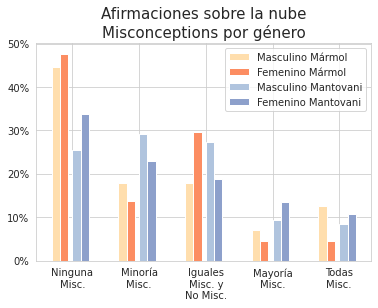

In [78]:
# Con misconception vs Sin Misconception - Agrupando No se - Afirmaciones sobre la nube
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["afirmaciones_nube"].str.replace(" ", "")
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["afirmaciones_nube"].str.replace(" ", "")

data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["afirmaciones_nube"].str.replace(" ", "")
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["afirmaciones_nube"].str.replace(" ", "")

dfs = [data_marmol_mas, data_marmol_fem, data_mantovani_mas, data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename( columns={0: "Masculino Mármol",
                                 1: "Femenino Mármol",
                                 2: "Masculino Mantovani",
                                 3: "Femenino Mantovani"}).fillna('0')

dfs = [result["Masculino Mármol"].apply(analizarMisc).value_counts(),
       result["Femenino Mármol"].apply(analizarMisc).value_counts(),
       result["Masculino Mantovani"].apply(analizarMisc).value_counts(),
       result["Femenino Mantovani"].apply(analizarMisc).value_counts()]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol",
                                1: "Femenino Mármol",
                                2: "Masculino Mantovani",
                                3: "Femenino Mantovani"})

result = result.reindex(["Sin\nRta.", 
                         "Ninguna\nMisc.",
                         "Minoría\nMisc.", 
                         "Iguales\nMisc. y\nNo Misc.",
                         "Mayoría\nMisc.",
                         "Todas\nMisc."])

# Restamos las no respuestas de los valores null de los correspondientes colegios y géneros.
result.at['Sin\nRta.', "Masculino Mármol"] = result.loc['Sin\nRta.',"Masculino Mármol"] - (cant_mantovani - cant_mantovani_otro) - cant_marmol_fem
result.at['Sin\nRta.', "Femenino Mármol"] = result.loc['Sin\nRta.',"Femenino Mármol"] - (cant_mantovani - cant_mantovani_otro) - cant_marmol_masc
result.at['Sin\nRta.', "Masculino Mantovani"] = result.loc['Sin\nRta.',"Masculino Mantovani"] - (cant_marmol - cant_marmol_otro) - cant_mantovani_fem
result.at['Sin\nRta.', "Femenino Mantovani"] = result.loc['Sin\nRta.',"Femenino Mantovani"] - (cant_marmol - cant_marmol_otro) - cant_mantovani_masc

result = result.drop('Sin\nRta.')

bar_width = 0.25

br1 = [1,3,5,7,9]
br2 = [x + bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x + bar_width for x in br3]

plt.bar(br1, result["Masculino Mármol"]   .div(cant_marmol_masc - nube_nose_marmol_masc)      , width=bar_width, label = "Masculino Mármol"   , color='navajowhite')
plt.bar(br2, result["Femenino Mármol"]    .div(cant_marmol_fem - nube_nose_marmol_fem)        , width=bar_width, label = "Femenino Mármol"    , color='C1')
plt.bar(br3, result["Masculino Mantovani"].div(cant_mantovani_masc - nube_nose_mantovani_masc), width=bar_width, label = "Masculino Mantovani", color='lightsteelblue')
plt.bar(br4, result["Femenino Mantovani"] .div(cant_mantovani_fem - nube_nose_mantovani_fem)  , width=bar_width, label = "Femenino Mantovani" , color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("Afirmaciones sobre la nube\nMisconceptions por género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_misco_agregadas_por_genero_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* Marmol: Ambos generos contestan en el 65% de los casos sin mayoría de misc.  Los varones eligen un conjunto de respuestas con mayoría de misc un 10% más que las chicas.
* Mantovani: Ambos generos contestan en el 55% sin mayoria de misc. No hay mayores diferencias en cuanto a mayoria de misc. 